In [18]:
import numpy as np
import pandas as pd

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [3]:
train_df = pd.read_csv(r'/train.csv')
test_df = pd.read_csv(r'/test.csv')
sample_df = pd.read_csv(r'/sample_submission.csv')

In [4]:
train_df

,customer_id,age,location,subscription_type,payment_plan,num_subscription_pauses,payment_method,customer_service_inquiries,signup_date,weekly_hours,average_session_length,song_skip_rate,weekly_songs_played,weekly_unique_songs,num_favorite_artists,num_platform_friends,num_playlists_created,num_shared_playlists,notifications_clicked,churned
0,1,32,Montana,Free,Yearly,2,Paypal,Medium,-1606,22.391362,105.394516,0.176873,169,109,18,32,52,35,46,0
1,2,64,New Jersey,Free,Monthly,3,Paypal,Low,-2897,29.294210,52.501115,0.981811,55,163,44,33,12,25,37,1
2,3,51,Washington,Premium,Yearly,2,Credit Card,High,-348,15.400312,24.703696,0.048411,244,117,20,129,50,28,38,0
3,4,63,California,Family,Yearly,4,Apple Pay,Medium,-2894,22.842084,83.595480,0.035691,442,252,47,120,55,17,24,0
4,5,54,Washington,Family,Monthly,3,Paypal,High,-92,23.151163,52.578266,0.039738,243,230,41,66,40,32,47,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124995,124996,32,California,Student,Monthly,4,Debit Card,Low,-1895,29.161399,7.176704,0.893839,460,22,18,199,71,41,41,0
124996,124997,56,Maine,Premium,Yearly,2,Debit Card,Low,-2778,44.744198,105.069363,0.668759,315,16,48,185,67,23,30,0
124997,124998,45,Maine,Family,Monthly,0,Paypal,Medium,-604,15.200073,78.064000,0.286604,11,206,48,40,78,40,28,0
124998,124999,69,Maine,Free,Monthly,4,Paypal,High,-2570,35.270053,20.921062,0.092528,451,108,15,41,3,35,9,1


#EDA (Added Code)

/tmp/ipykernel_667/779864090.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x=col, palette='viridis')


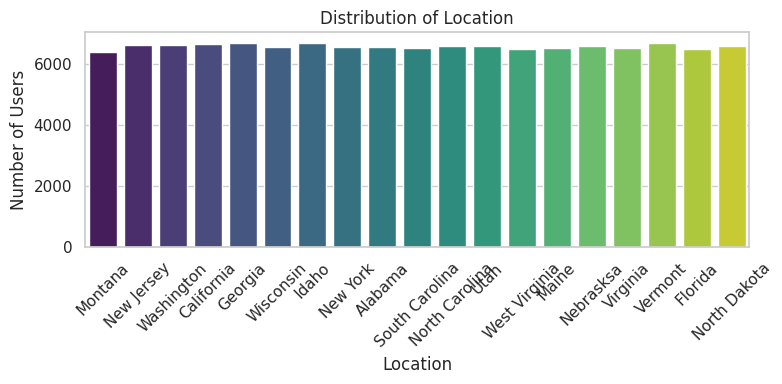

/tmp/ipykernel_667/779864090.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x=col, palette='viridis')


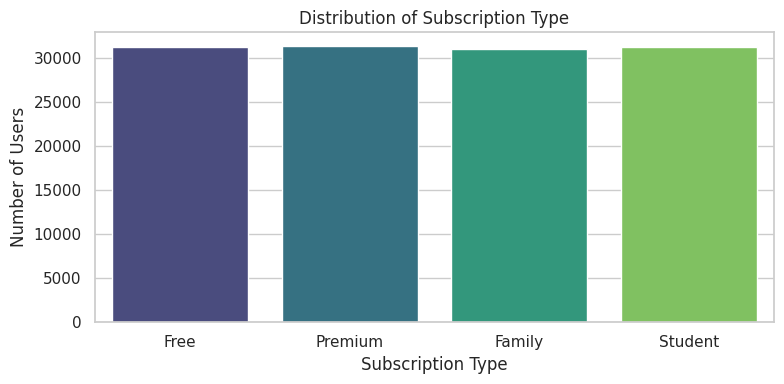

/tmp/ipykernel_667/779864090.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x=col, palette='viridis')


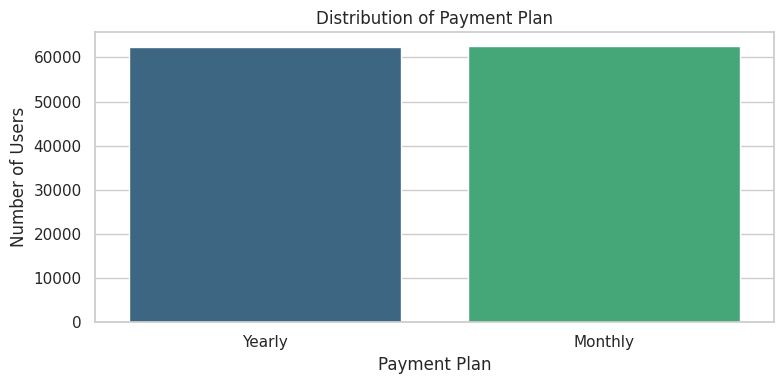

/tmp/ipykernel_667/779864090.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x=col, palette='viridis')


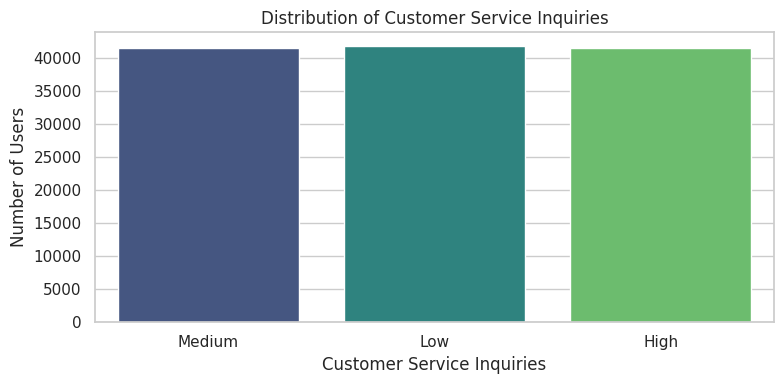

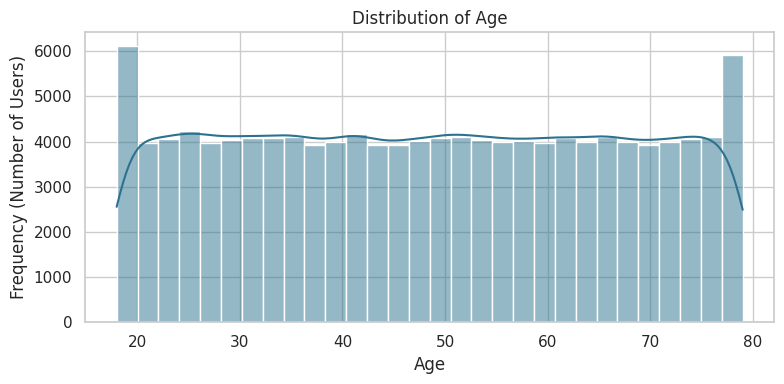

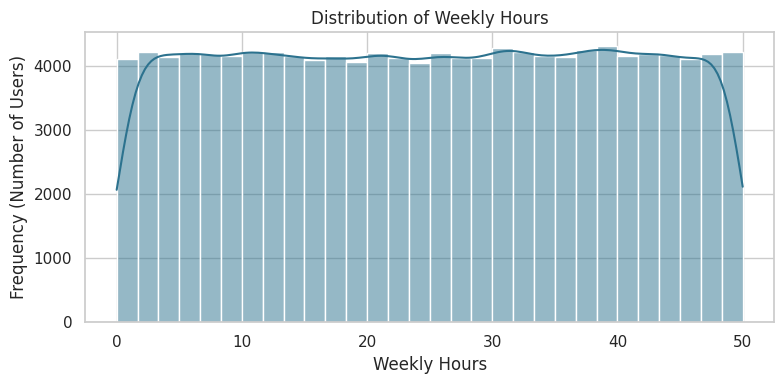

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

#Set the visual style for the plots
sns.set_theme(style="whitegrid")

# Define our feature categories
categorical_features = [
    'location',
    'subscription_type',
    'payment_plan',
    'customer_service_inquiries' #Treating as categorical since it's discrete integers (0, 1, 2, etc.)
]

continuous_features = [
    'age',
    'weekly_hours'
]

#1. Plot the Categorical Distributions
for col in categorical_features:
    #Check if the column exists to avoid errors
    if col in train_df.columns:
        plt.figure(figsize=(8, 4))
        #Use countplot for categorical/discrete data
        sns.countplot(data=train_df, x=col, palette='viridis')
        plt.title(f'Distribution of {col.replace("_", " ").title()}')
        plt.ylabel('Number of Users')
        plt.xlabel(col.replace("_", " ").title())
        plt.xticks(rotation=45 if train_df[col].nunique() > 5 else 0) # Rotate labels if there are many categories
        plt.tight_layout()
        plt.show()

#2. Plot the Continuous Distributions
for col in continuous_features:
    if col in train_df.columns:
        plt.figure(figsize=(8, 4))
        #Use histplot for continuous data, add a KDE (Kernel Density Estimate) line
        sns.histplot(data=train_df, x=col, kde=True, bins=30, color='#2c728e')
        plt.title(f'Distribution of {col.replace("_", " ").title()}')
        plt.ylabel('Frequency (Number of Users)')
        plt.xlabel(col.replace("_", " ").title())
        plt.tight_layout()
        plt.show()

/tmp/ipykernel_667/1460277449.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=train_df, x='churned', palette='viridis')


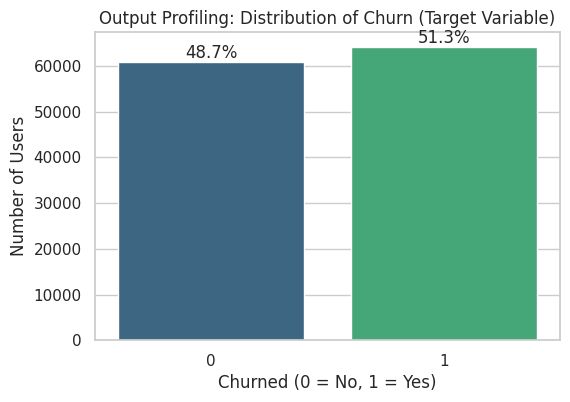

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

#Set visual style
sns.set_theme(style="whitegrid")

#1. Output Profiling: Distribution of Churn
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=train_df, x='churned', palette='viridis')
plt.title('Output Profiling: Distribution of Churn (Target Variable)')
plt.xlabel('Churned (0 = No, 1 = Yes)')
plt.ylabel('Number of Users')

#Add percentages on top of bars
total = len(train_df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

plt.show()

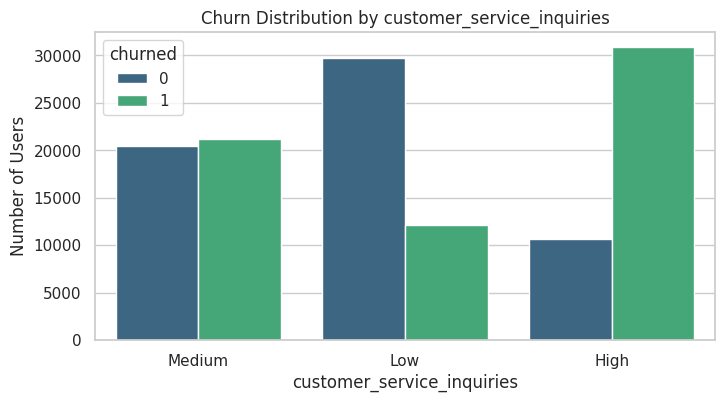

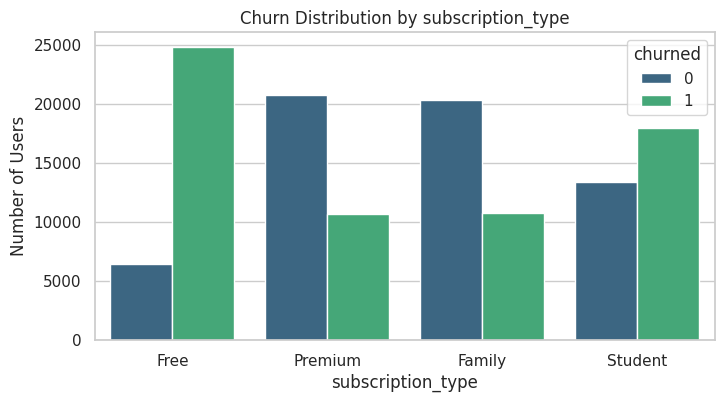

In [8]:
#Profile Key Demographic/Categorical Inputs

#2. Input Profiling: Categorical Features
categorical_cols_to_profile = ['customer_service_inquiries', 'subscription_type']

for col in categorical_cols_to_profile:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=train_df, x=col, hue='churned', palette='viridis')
    plt.title(f'Churn Distribution by {col}')
    plt.ylabel('Number of Users')
    plt.show()

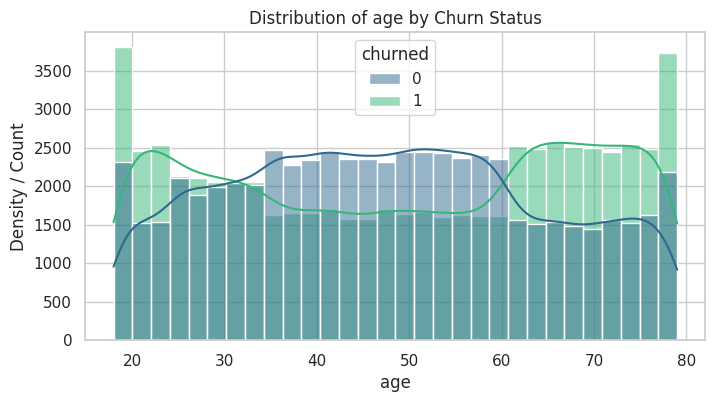

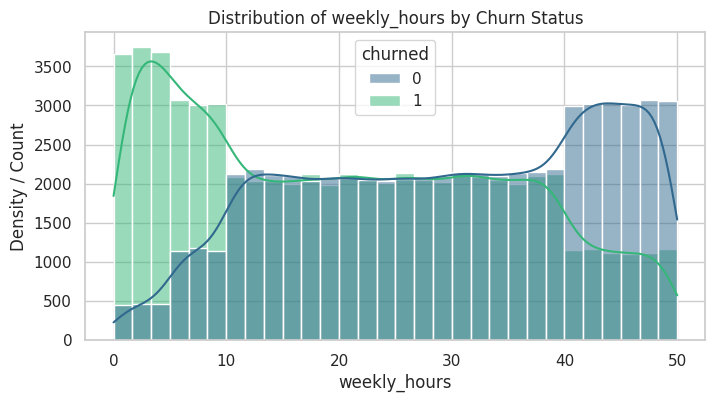

In [9]:
#3. Input Profiling: Numerical Features
numeric_cols_to_profile = ['age', 'weekly_hours']

for col in numeric_cols_to_profile:
    #Check if column exists in the dataframe first
    if col in train_df.columns:
        plt.figure(figsize=(8, 4))
        sns.histplot(data=train_df, x=col, hue='churned', kde=True, bins=30, palette='viridis')
        plt.title(f'Distribution of {col} by Churn Status')
        plt.ylabel('Density / Count')
        plt.show()

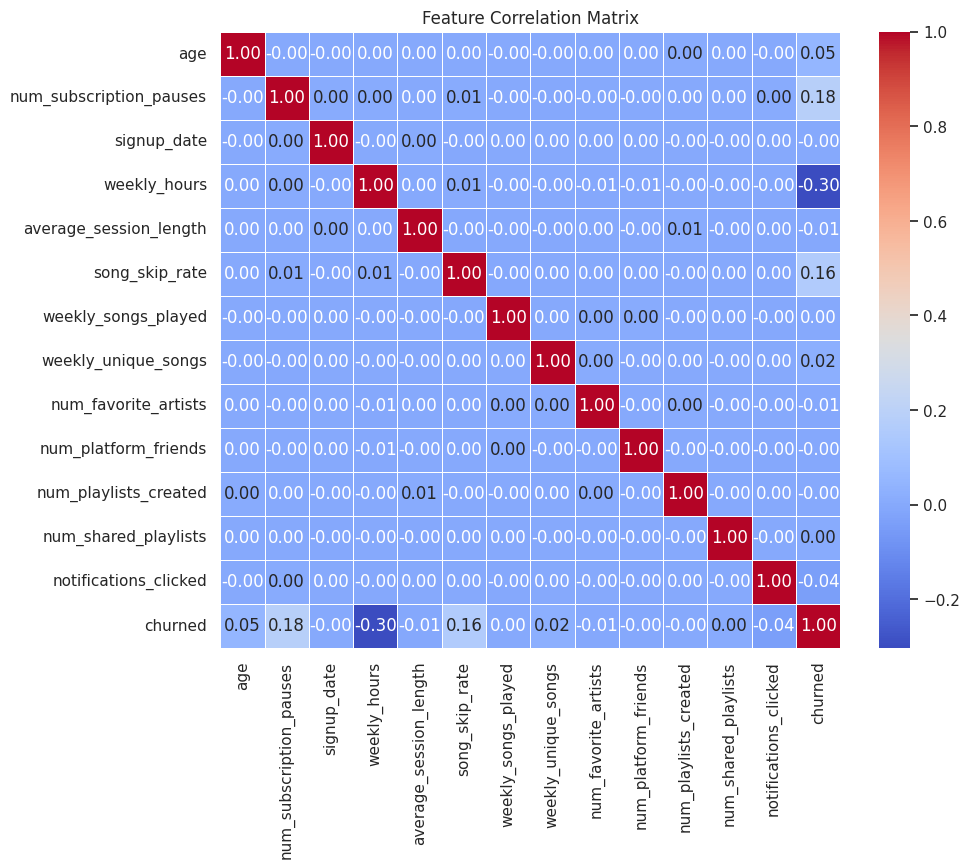

In [10]:
# 4. Correlation Matrix of all Numerical Features
plt.figure(figsize=(10, 8))

#Select only numeric columns for correlation to avoid errors
numeric_df = train_df.select_dtypes(include=['int64', 'float64'])

#Drop customer_id as it's just an identifier, not a predictive feature
if 'customer_id' in numeric_df.columns:
    numeric_df = numeric_df.drop(columns=['customer_id'])

#Calculate and plot correlation
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

# Preprocessing

In [11]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

train_df['customer_service_inquiries'] = train_df['customer_service_inquiries'].map({'Low':0,'Medium':1,'High':2})
test_df['customer_service_inquiries'] = test_df['customer_service_inquiries'].map({'Low':0,'Medium':1,'High':2})

num_features = train_df.select_dtypes(['int64','float64']).columns.tolist()
num_features.remove('churned')
num_features.remove('customer_id')
print(num_features)

cat_features = train_df.select_dtypes('object').columns.tolist()
print(cat_features)

num_transformer = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('onehot',OneHotEncoder(handle_unknown = 'ignore'))
])

preprocessor = ColumnTransformer(
    transformers = [
        ('num',num_transformer,num_features),
        ('cat',cat_transformer,cat_features)
    ]
)

X = train_df.drop(columns=['customer_id','churned'])
y = train_df['churned']
X = preprocessor.fit_transform(X)

print(X)
print(X.shape)

['age', 'num_subscription_pauses', 'customer_service_inquiries', 'signup_date', 'weekly_hours', 'average_session_length', 'song_skip_rate', 'weekly_songs_played', 'weekly_unique_songs', 'num_favorite_artists', 'num_platform_friends', 'num_playlists_created', 'num_shared_playlists', 'notifications_clicked']
['location', 'subscription_type', 'payment_plan', 'payment_method']
[[-0.91694113  0.00624896  0.00283933 ...  0.          0.
   1.        ]
 [ 0.87067146  0.71186818 -1.22101006 ...  0.          0.
   1.        ]
 [ 0.14445385  0.00624896  1.22668872 ...  1.          0.
   0.        ]
 ...
 [-0.19072352 -1.40498947  0.00283933 ...  0.          0.
   1.        ]
 [ 1.14998593  1.41748739  1.22668872 ...  0.          0.
   1.        ]
 [-1.69902164  1.41748739 -1.22101006 ...  0.          0.
   0.        ]]
(125000, 43)


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X ,y ,test_size = 0.2,random_state = 42)

In [13]:
import torch
from torch import nn, optim
from torch.nn import functional as F
from torch.utils.data import DataLoader, TensorDataset

MLP = nn.Sequential(
    nn.Linear(X_train.shape[1],64),
    nn.ReLU(),
    nn.Linear(64,32),
    nn.ReLU(),
    nn.Linear(32,16),
    nn.ReLU(),
    nn.Linear(16,1),
    nn.Sigmoid()
)

epochs = 30
loss_fn = nn.BCELoss()
optimizer = optim.AdamW(MLP.parameters(),lr=3e-4)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)

dataset = TensorDataset(X_train_tensor, y_train_tensor)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

for epoch in range(epochs):
    train_loss = 0
    MLP.train()
    num = 0
    for x_batch, y_batch in dataloader:
        optimizer.zero_grad()
        output = MLP(x_batch)
        loss = loss_fn(output, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        num += 1
    output = MLP(X_val_tensor)
    val_loss = loss_fn(output,y_val_tensor).item()
    print(f'finished epoch {epoch+1}, training loss is {train_loss}, validation loss is {val_loss}')

finished epoch 1, training loss is 1328.64912250638, validation loss is 0.38626500964164734
finished epoch 2, training loss is 1179.0820722281933, validation loss is 0.3746921122074127
finished epoch 3, training loss is 1159.4517398923635, validation loss is 0.37020644545555115
finished epoch 4, training loss is 1147.6587927788496, validation loss is 0.3696063756942749
finished epoch 5, training loss is 1137.8287885636091, validation loss is 0.369742214679718
finished epoch 6, training loss is 1118.403143554926, validation loss is 0.3579951226711273
finished epoch 7, training loss is 1091.1774570271373, validation loss is 0.34958648681640625
finished epoch 8, training loss is 1067.422734476626, validation loss is 0.34377580881118774
finished epoch 9, training loss is 1055.053645312786, validation loss is 0.34459707140922546
finished epoch 10, training loss is 1049.5730451717973, validation loss is 0.33968663215637207
finished epoch 11, training loss is 1045.5622702687979, validation lo

# Validation (Added Code)

In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

#1. Put the model in evaluation mode and get predictions for the validation set
MLP.eval()
with torch.no_grad():
    val_probabilities = MLP(X_val_tensor).squeeze()
    val_predictions = (val_probabilities > 0.5).int()

#Convert tensors back to numpy arrays for sklearn metrics
y_true = y_val_tensor.numpy()
y_pred = val_predictions.numpy()
y_prob = val_probabilities.numpy()

#2. Calculate the metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_prob)

#3. Print the results nicely
print("--- Baseline Validation Metrics ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"AUC-ROC:   {auc:.4f}")

--- Baseline Validation Metrics ---
Accuracy:  0.8400
Precision: 0.8329
Recall:    0.8613
F1-Score:  0.8469
AUC-ROC:   0.9318


In [14]:
Test_X = test_df.drop(columns=['customer_id'])
Test_X = preprocessor.fit_transform(Test_X)
Test_Tensor = torch.tensor(Test_X,dtype=torch.float32)
results = MLP(Test_Tensor)

In [15]:
results = (results > 0.5).int()
print(results)

tensor([[1],
        [1],
        [1],
        ...,
        [1],
        [0],
        [1]], dtype=torch.int32)


In [16]:
submission_file = pd.DataFrame({
    'customer_id': test_df['customer_id'],
    'churned': results.flatten()
})
submission_file.to_csv('submission.csv', index = False)